---
numbering: false
---

# 5.3. Singular Value Decomposition

:::{danger} **This section is currently under construction!**
:::

Eigenvalues and eigenvectors are powerful concepts, but unfortunately, they only apply to square matrices. It would be nice if we could extend some of their utility to non-square matrices, like matrices containing real data, which typically have many more rows than columns.

This is precisely where the **singular value decomposition** (SVD) comes in. You should think of it as a generalization of the eigenvalue decomposition, $A = V \Lambda V^{-1}$, to non-square matrices. When we first introduced eigenvalues and eigenvectors, we said that an eigenvector $\vec v$ of $A$ is a vector whose direction is unchanged when multiplied by $A$ – all that happens to $\vec v$ is that it's scaled by a factor of $\mathcal{\lambda}$.

$$A \vec v = \lambda \vec v$$

But now, suppose $X$ is some $n \times d$ matrix. For any vector $\vec v \in \mathbb{R}^d$, the vector $X \vec v$ is in $\mathbb{R}^n$, **not** $\mathbb{R}^d$, meaning $\vec v$ and $X \vec v$ live in different universes. So, it can't make sense to say that $X \vec v$ results from stretching $\vec v$.

Instead, we'll find pairs of **singular vectors**, $\vec v \in \mathbb{R}^d$ and $\vec u \in \mathbb{R}^n$, such that

$$A \vec v = \sigma \vec u$$

where $\mathcal{\sigma}$ is a **singular value** of $A$ (not a standard deviation!). Intuitively, this says that when $X$ is multiplied by $\vec v$, the result is a scaled version of $\vec u$. These singular values and vectors are the focus of Chapter 5.3. Applications of the singular value decomposition come in Chapter 5.4.

---

## Introduction

I'll start by giving you the definition of the SVD, and then together we'll figure out where it came from.

:::{note} Definition: Singular Value Decomposition
Suppose $X$ is any $n \times d$ matrix (that is, **not necessarily square**). Then, there exists a **singular value decomposition** of $X$ of the form

$$X = U \Sigma V^T$$

where:
- $U$ is an $n \times n$ orthogonal matrix, whose columns are called the **left singular vectors** of $X$
- $\mathcal{\Sigma}$ is an $n \times d$ diagonal matrix with non-negative real numbers on the diagonal and zeros elsewhere
- $V$ is a $d \times d$ orthogonal matrix, whose columns are called the **right singular vectors** of $X$

The diagonal entries of $\mathcal{\Sigma}$ are called the **singular values** of $X$. Typically, the singular values are sorted in decreasing order, i.e. $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$, where $r = \text{rank}(X)$.
:::

Firstly, note that the SVD exists, no matter what $X$ is: it can be non-square, and it doesn't even need to be full rank. But note that unlike in the eigenvalue decomposition, where we decomposed $A$ using just one eigenvector matrix $V$ and a diagonal matrix $\mathcal{\Lambda}$, here we need to use two **singular vector** matrices $U$ and $V$ and a diagonal matrix $\mathcal{\Sigma}$.

There's a lot of notation and new concepts above. Let's start with an example, then try and understand where each piece in $X = U \Sigma V^T$ comes from and means. Suppose

$$
X = \begin{bmatrix}
3 & 2 & 5 \\
2 & 3 & 5 \\
2 & -2 & 0 \\
5 & 5 & 10
\end{bmatrix}
$$

$X$ is a $4 \times 3$ matrix with $\text{rank}(X) = 2$, since its third column is the sum of the first two. Its singular value decomposition is given by $X = U \Sigma V^T$:

$$X = \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

Two important observations:

1. $U$ and $V$ are both orthogonal matrices, meaning $U^TU = UU^T = I_{4 \times 4}$ and $V^TV = VV^T = I_{3 \times 3}$.
1. $\mathcal{\Sigma}$ contains the singular values of $X$ on the diagonal, arranged in decreasing order. We have that $\sigma_1 = 15$, $\sigma_2 = 3$, and $\sigma_3 = 0$. $X$ has three singular values, but only two are non-zero. **In general, the number of non-zero singular values is equal to the rank of $X$**.

Where did all of these numbers come from?

---

## Discovering the SVD

The SVD of $X$ depends heavily on the matrices $X^TX$ and $XX^T$. While $X$ itself is $4 \times 3$, 
- $X^TX$ is a **symmetric $3 \times 3$ matrix**, containing the dot products of $X$'s columns
- $XX^T$ is a **symmetric $4 \times 4$ matrix**, containing the dot products of $X$'s rows

Since $X^TX$ and $XX^T$ are both square matrices, they have eigenvalues and eigenvectors. And since they're both symmetric, their eigenvectors for different eigenvalues are orthogonal to each other, as the spectral theorem $A = Q \Lambda Q^T$ guarantees for any symmetric matrix $A$. 

### Singular Values and Singular Vectors

The singular value decomposition involves creatively using the eigenvalues and eigenvectors of $X^TX$ and $XX^T$. Suppose $X = U \Sigma V^T$ is the SVD of $X$. Then, using the facts that $U^TU = I$ and $V^TV = I$, we have:

$$X^TX = (U \Sigma V^T)^T (U \Sigma V^T) = V \Sigma^T \underbrace{U^T U}_{I} \Sigma V^T = \underbrace{V \Sigma^T \Sigma V^T}_{\text{looks like } Q \Lambda Q^T}$$

$$XX^T = (U \Sigma V^T) (U \Sigma V^T)^T = U \Sigma \underbrace{V^T V}_{I} \Sigma^T U^T = \underbrace{U \Sigma \Sigma^T U^T}_{\text{looks like } P \Lambda P^T}$$

**This just looks like we diagonalized $X^TX$ and $XX^T$!** The expressions above are saying that:
- $V$'s columns are the eigenvectors of $X^TX$
- $U$'s columns are the eigenvectors of $XX^T$

$X^TX$ and $XX^T$ usually have different sets of eigenvectors, which is why $U$ and $V$ are generally not the same matrix (they don't even have the same shape).

The eigen**values** of $X^TX$ and $XX^T$ **are the same**, though: those are the non-zero entries of $\Sigma^T \Sigma$ and $\Sigma \Sigma^T$. Since $\mathcal{\Sigma}$ is an $n \times d$ matrix, $\Sigma^T \Sigma$ is a $d \times d$ matrix and $\Sigma \Sigma^T$ is an $n \times n$ matrix. But, when you work out both products, you'll notice that their non-zero values are the same.

Suppose for example that $\Sigma = \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix}$. Then,

$$\Sigma^T \Sigma = \begin{bmatrix} \sigma_1 & 0 & 0 & 0 \\ 0 & \sigma_2 & 0 & 0 \\ 0 & 0 & \sigma_3 & 0 \end{bmatrix} \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix} = \begin{bmatrix} \sigma_1^2 & 0 & 0 \\ 0 & \sigma_2^2 & 0 \\ 0 & 0 & \sigma_3^2\end{bmatrix}$$

$$\Sigma \Sigma^T = \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix} \begin{bmatrix} \sigma_1 & 0 & 0 & 0 \\ 0 & \sigma_2 & 0 & 0 \\ 0 & 0 & \sigma_3 & 0 \end{bmatrix} = \begin{bmatrix} \sigma_1^2 & 0 & 0 & 0 \\ 0 & \sigma_2^2 & 0 & 0 \\ 0 & 0 & \sigma_3^2 & 0 \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

But, these matrices with the squared terms are precisely the $\mathcal{\Lambda}$'s in the spectral decompositions of $X^TX = Q \Lambda Q^T$ and $XX^T = P \Lambda P^T$. This means that $$\sigma_i^2 = \lambda_i \implies \sigma_i = \sqrt{\lambda_i}$$

where $\sigma_i$ is a singular value of $X$ and $\lambda_i$ is an eigenvalue of $X^TX$ or $XX^T$.

The above derivation is enough to justify that the eigenvalues of $X^TX$ and $XX^T$ are never negative, but for another perspective, note that both $X^TX$ and $XX^T$ are **positive semidefinite**, meaning their eigenvalues are non-negative. (You're wrestling with this fact in Lab 11 and Homework 10.)

:::{attention} The relationship between singular values/vectors and eigenvalues/vectors

To summarize: in $X = U \Sigma V^T$,
- The columns of $U$ – called the **left singular vectors** of $X$ – are the eigenvectors of $XX^T$
- The columns of $V$ – called the **right singular vectors** of $X$ – are the eigenvectors of $X^TX$
- The **singular values** of $X$, which live on the diagonal of $\mathcal{\Sigma}$, are the **square roots of the eigenvalues** of $X^TX$ and $XX^T$: $$\sigma_i = \sqrt{\lambda_i}$$
:::


:::{tip} Another proof that $X^TX$ and $XX^T$ have the same non-zero eigenvalues
:class: dropdown

Above, we implicitly used the fact that $X^TX$ and $XX^T$ have the same non-zero eigenvalues. Here's a proof of this fact that has nothing to do with the SVD.

Suppose $\vec v_i$ is an eigenvector of $X^TX$ with eigenvalue $\lambda_i$.

$$X^TX \vec v_i = \lambda_i \vec v_i$$

What happens if we multiply both sides on the left by $X$?

$$XX^TX \vec v_i = X \lambda_i \vec v_i$$

Creatively adding parentheses gives us

$$XX^T (X \vec v_i) = \lambda_i (X \vec v_i)$$

This shows that $X \vec v_i$ is an eigenvector of $XX^T$ with eigenvalue $\lambda_i$. The important thing is that the eigenvalue is shared. This logic can be reversed too, to show that if $\vec u_i$ is an eigenvector of $XX^T$ with eigenvalue $\lambda_i$, then $\lambda_i$ is also an eigenvalue of $X^TX$.
:::

### Computing the SVD

To find $U$, $\mathcal{\Sigma}$, and $V^T$, we don't actually need to compute both $X^TX$ and $XX^T$: all of these quantities can be uncovered just with one of them.

Let's return to our example, $X = \begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}$. Using what we've just learned, let's find $U$, $\mathcal{\Sigma}$, and $V^T$ ourselves. $X^TX$ has fewer entries than $XX^T$, so let's start with it. I will delegate _some_ number crunching to `numpy`.

In [156]:
X = np.array([[3, 2, 5],
              [2, 3, 5],
              [2, -2, 0],
              [5, 5, 10]])
X.T @ X

array([[ 42,  33,  75],
       [ 33,  42,  75],
       [ 75,  75, 150]])

$X^TX$ is a $3 \times 3$ matrix, but its rank is 2, meaning it will have an eigenvalue of $0$. What are its other eigenvalues?

In [158]:
np.set_printoptions(precision=0, suppress=True)

In [162]:
eigvals, eigvecs = np.linalg.eig(X.T @ X)
eigvals

array([225.,   9.,   0.])

The eigenvalues of $X^TX$ are $225$, $9$, and $0$. This tells us that the singular values of $X$ are $\sqrt{225} = 15$, $\sqrt{9} = 3$, and $0$. So far, we've discovered that $\mathcal{\Sigma} = \begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}$. Remember that $\mathcal{\Sigma}$ always has the same shape as $X$ (both are $n \times d$), and all of its entries are 0 except for the singular values, which are arranged in decreasing order on the diagonal, starting with the largest singular value in the top left corner.

Let's now find the eigenvectors of $X^TX$ – that is, the right singular vectors of $X$ – which we should store in $V$. **We expect the eigenvectors $\vec v_i$ of $X^TX$to be orthogonal**, since $X^TX$ is symmetric.

In [178]:
X.T @ X

array([[ 42,  33,  75],
       [ 33,  42,  75],
       [ 75,  75, 150]])

- For $\lambda_1 = 225$, one eigenvector is $\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix}$, since

$$\underbrace{\begin{bmatrix} 42 & 33 & 75 \\ 33 & 42 & 75 \\ 75 & 75 & 150 \end{bmatrix}}_{X^TX} \begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix} = \begin{bmatrix} 225 \\ 225 \\ 450 \end{bmatrix} = 225 \begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix}$$

- For $\lambda_2 = 9$, one eigenvector is $\vec v_2 = \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$, since

$$\begin{bmatrix} 42 & 33 & 75 \\ 33 & 42 & 75 \\ 75 & 75 & 150 \end{bmatrix} \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix} = \begin{bmatrix} 9 \\ -9 \\ 0 \end{bmatrix} = 9 \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$$

- For $\lambda_3 = 0$, one eigenvector is $\vec v_3 = \begin{bmatrix} 1 \\ 1 \\ -1 \end{bmatrix}$, since

$$\begin{bmatrix} 42 & 33 & 75 \\ 33 & 42 & 75 \\ 75 & 75 & 150 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \\ -1 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

Note that $\vec v_3$ is a basis for $\text{nullsp}(X)$, since $\text{dim}(\text{nullsp}(X)) = 1$ and $X \vec v_3 = \vec 0$. Hold that thought for now.

To create $V$, all we need to do is turn $\vec v_1$, $\vec v_2$, and $\vec v_3$ into unit vectors.

$$\begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} \\ \frac{1}{\sqrt{6}} \\ \frac{2}{\sqrt{6}} \end{bmatrix}}_{\vec v_1}, \quad \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \\ 0 \end{bmatrix}}_{\vec v_2}, \quad \begin{bmatrix} 1 \\ 1 \\ -1 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} \frac{1}{\sqrt{3}} \\ \frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \end{bmatrix}}_{\vec v_3}$$

Stacking these unit vectors together gives us $V$:

$$V = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{3}} \\ 
                      \frac{1}{\sqrt{6}} & -\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{3}} \\ 
                      \frac{2}{\sqrt{6}} & 0 & -\frac{1}{\sqrt{3}} \end{bmatrix}$$

And indeed, since $X^TX$ is symmetric, $V$ is orthogonal: $V^TV = VV^T = I_{3 \times 3}$.

Great! We're almost done computing the SVD. So far, we have

$$\underbrace{\begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}}_X = U \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

### $XV = U \Sigma$ and $X \vec v_i = \sigma_i \vec u_i$

Ideally, we can avoid having to compute the eigenvectors of $XX^T$ to stack into $U$. And we can. If we start with

$$X = U \Sigma V^T$$

and multiply both sides on the right by $V$, we uncover a relationship between the columns of $U$ and the columns of $V$.

$$XV = U \Sigma$$

Let's unpack this. On the left, the matrix $XV$ is made up of multiplying $X$ by each column of $V$.

$$XV = X_{4 \times 3} \begin{bmatrix} | & | & | \\ \vec v_1 & \vec v_2 & \vec v_3 \\ | & | & | \end{bmatrix}_{3 \times 3} = \begin{bmatrix} | & | & | \\ X \vec v_1 & X \vec v_2 & X \vec v_3 \\ | & | & | \end{bmatrix}_{4 \times 3}$$

On the right, $U \Sigma$ is made up of stretching each column of $U$ by the corresponding singular value in the diagonal of $\mathcal{\Sigma}$.

$$U \Sigma = \begin{bmatrix} | & | & | & | \\ \vec u_1 & \vec u_2 & \vec u_3 & \vec u_4 \\ | & | & | & | \end{bmatrix}_{4 \times 4} \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix}_{4 \times 3} = \begin{bmatrix} | & | & | \\ \sigma_1 \vec u_1 & \sigma_2 \vec u_2 & \sigma_3 \vec u_3 \\ | & | & | \end{bmatrix}_{4 \times 3}$$

But, since $XV = U \Sigma$, we have

$$\begin{bmatrix} | & | & | \\ X \vec v_1 & X \vec v_2 & X \vec v_3 \\ | & | & | \end{bmatrix} = \begin{bmatrix} | & | & | \\ \sigma_1 \vec u_1 & \sigma_2 \vec u_2 & \sigma_3 \vec u_3 \\ | & | & | \end{bmatrix}$$

:::{attention} Singular values represent stretches, too!
A consequence of the above relationship is that if $X$ is $n \times d$, then for $i = 1, 2, ..., d$,

$$X \vec v_i = \sigma_i \vec u_i$$

**The above is saying that when $X$ is multiplied by $\vec v_i$, the result is a scaled version of $\vec u_i$ (not $\vec v_i$)!** 

As we said at the start of the section, $X \vec v_i$ lives in a different universe $(\mathbb{R}^n)$ than $\vec v_i$ does $(\mathbb{R}^d)$, so $\vec v_i$ and $X \vec v_i$ can't point in the same direction; instead, $X \vec v_i$ points in the same direction as $\vec u_i$, which lives in $\mathbb{R}^n$.

$X \vec v_i = \sigma_i \vec u_i$ is the singular value/vector analog of $A \vec v = \lambda \vec v$ for eigenvalues/eigenvectors.
:::

**Crucially though**, $X \vec v_i = \sigma_i \vec u_i$ only holds when we've arranged the singular values and vectors in $U$, $\mathcal{\Sigma}$, and $V^T$ consistently. This is one reason why we always arrange the singular values in $\mathcal{\Sigma}$ in decreasing order.

Back to our example. Again, we currently have

$$\underbrace{\begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}}_X = U \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

We know $X$, and we know each $\vec v_i$ and $\sigma_i$. Rearranging $X \vec v_i = \sigma_i \vec u_i$ gives us

$$\vec u_i = \frac{1}{\sigma_i} X \vec v_i$$

which is a recipe for computing $\vec u_1$, $\vec u_2$, and $\vec u_3$.

1. $\vec u_1 = \frac{1}{15} X \begin{bmatrix} \frac{1}{\sqrt{6}} \\ \frac{1}{\sqrt{6}} \\ \frac{2}{\sqrt{6}} \end{bmatrix} = \begin{bmatrix} \frac{1}{\sqrt{6}} \\ \frac{1}{\sqrt{6}} \\ 0 \\ \frac{2}{\sqrt{6}} \end{bmatrix}$
1. $\vec u_2 = \frac{1}{3} X \begin{bmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \\ 0 \end{bmatrix} = \begin{bmatrix} \frac{1}{3\sqrt{2}} \\ -\frac{1}{3\sqrt{2}} \\ \frac{2\sqrt{2}}{3} \\ 0 \end{bmatrix}$
1. $\vec u_3 = \frac{1}{0} X \begin{bmatrix} \frac{1}{\sqrt{3}} \\ \frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \end{bmatrix} = ... \text{wait, what?}$

Something is not quite right: $\sigma_3 = 0$, which means we can't use $\vec u_i = \frac{1}{\sigma_i} X \vec v_i$ to compute $\vec u_3$. And, even if we could, this recipe tells us nothing about $\vec u_4$, which we also need to find, since $U$ is $4 \times 4$.

### Null Spaces Return

So far, we've found two of the four columns of $U$.

$$U = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & ? & ? \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & ? & ? \\ 0 & \frac{2\sqrt{2}}{3} & ? & ? \\ \frac{2}{\sqrt{6}} & 0 & ? & ? \end{bmatrix}$$

The issue is that we don't have a recipe for what $\vec u_3$ and $\vec u_4$ should be. This problem stems from the fact that $\text{rank}(X) = 2$.

$$X = \begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}$$

If we were to compute $XX^T$, whose eigenvectors are the columns of $U$, we would have seen that it has an eigenvalue of $0$ with geometric (and algebraic) multiplicity 2.

In [221]:
X @ X.T

array([[ 38,  37,   2,  75],
       [ 37,  38,  -2,  75],
       [  2,  -2,   8,   0],
       [ 75,  75,   0, 150]])

In [222]:
eigvals, eigvecs = np.linalg.eig(X @ X.T)
eigvals


array([225.,   9.,  -0.,   0.])

So, all we need to do is fill $\vec u_3$ and $\vec u_4$ with two orthonormal vectors that span the eigenspace of $XX^T$ for eigenvalue 0. This will "complete" $U$ to be a basis for $\mathbb{R}^4$, which it needs to be to be an invertible square matrix. (Remember, $U$ must satisfy $U^T U = UU^T = I$, which means $U$ is invertible.)

 **But, the eigenspace of $XX^T$ for eigenvalue 0 is $\text{nullsp}(XX^T)$!**

Since $XX^T$ is symmetric, $\vec u_3$ and $\vec u_4$ will be orthogonal to $\vec u_1$ and $\vec u_2$ no matter what, since $\vec u_1$ and $\vec u_2$ are eigenvectors of $XX^T$ for eigenvalues 225 and 9, respectively.

Observe that

- $\begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix}$ is in $\text{nullsp}(XX^T)$, since $\begin{bmatrix}
38 & 37 & 2 & 75 \\
37 & 38 & -2 & 75 \\
2 & -2 & 8 & 0 \\
75 & 75 & 0 & 150 \\\end{bmatrix} \begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$
- $\begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix}$ is in $\text{nullsp}(XX^T)$, since $\begin{bmatrix}
38 & 37 & 2 & 75 \\
37 & 38 & -2 & 75 \\
2 & -2 & 8 & 0 \\
75 & 75 & 0 & 150 \\\end{bmatrix} \begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$

The vectors $\begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix}$ are orthogonal to each other, so they're good candidates for $\vec u_3$ and $\vec u_4$, we just need to normalize them first.

$$
\begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} -\frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \\ 0 \\ \frac{1}{\sqrt{3}} \end{bmatrix}}_{\vec u_3}, \quad \begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} -\frac{2}{3} \\ \frac{2}{3} \\ \frac{1}{3} \\ 0 \end{bmatrix}}_{\vec u_4}
$$

Before we place $\vec u_3$ and $\vec u_4$ in $U$, it's worth noticing that $\vec u_3$ and $\vec u_4$ are both in $\text{nullsp}(X^T)$ too.

$$X^T \vec u_3 = \begin{bmatrix} 3 & 2 & 2 & 5 \\ 2 & 3 & -2 & 5 \\ 5 & 5 & 0 & 10 \end{bmatrix} \begin{bmatrix} -\frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \\ 0 \\ \frac{1}{\sqrt{3}} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

$$X^T \vec u_4 = \begin{bmatrix} 3 & 2 & 2 & 5 \\ 2 & 3 & -2 & 5 \\ 5 & 5 & 0 & 10 \end{bmatrix} \begin{bmatrix} -\frac{2}{3} \\ \frac{2}{3} \\ \frac{1}{3} \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

In fact, remember from [Chapter 2.8](../vectors-and-matrices/rank#example-rank-of-x-tx) that

$$\text{nullsp}(X^T) = \text{nullsp}(XX^T) \qquad \text{and} \qquad \text{nullsp}(X) = \text{nullsp}(X^TX)$$

So, we have

$$U = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}$$

And finally, we have computed the SVD of $X$!

$$\underbrace{\begin{bmatrix}
3 & 2 & 5 \\
2 & 3 & 5 \\
2 & -2 & 0 \\
5 & 5 & 10
\end{bmatrix}}_X = \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

For the most part, we will use `numpy` to compute the SVD of a matrix. But, it's important to understand the steps we took to compute the SVD manually.

:::{attention} Finding the SVD by hand
To conclude, we found $X = U \Sigma V^T$ by:
1. Computing $X^TX$.
1. Finding the eigenvalues of $X^TX$; their square roots are the singular values of $X$. $$\sigma_i = \sqrt{\lambda_i}$$These singular values are placed in the diagonal of $\mathcal{\Sigma}$ in decreasing order.
1. For each eigenvalue $\lambda_i$, finding an orthonormal eigenvector $\vec v_i$ of $X^TX$ and placing it in the $i$th column of $V$.
1. For each $i = 1, 2, ..., r$, finding $\vec u_i$ by solving $$\vec u_i = \frac{1}{\sigma_i} X \vec v_i$$ and placing it in the $i$th column of $U$.
1. Filling the rest of $U$ with orthonormal vectors that form a basis for $\text{nullsp}(X^T)$.

---

## Examples

Let's work through a few problems – some computational, some more conceptual – that test our understanding of the SVD.

### Example: SVD of a $2 \times 2$ Matrix

We developed the SVD to decompose non-square matrices. But, it still works for square matrices too. Find the SVD of $X = \begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix}$.

### Example: SVD of a Positive Semidefinite Matrix

Let $X = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$, which is a positive semidefinite matrix (meaning it is symmetric and all of its eigenvalues are non-negative). Find the SVD of $X$. How does it compare to the spectral decomposition of $X$ into $Q \Lambda Q^T$?

### Example: SVD of an Orthogonal Matrix

Suppose $X$ itself is an $n \times n$ orthogonal matrix, meaning $X^TX = XX^T = I$. Why are all of $X$'s singular values 1?

:::{seealso} Solution
:class: dropdown

Recall, in $X = U \Sigma V^T$, the columns of $U$ are the eigenvectors of $XX^T$ and the columns of $V$ are the eigenvectors of $X^TX$. But here, $X^TX = XX^T = I_{n \times n}$. The $n \times n$ identity matrix has the unique eigenvalue of $1$ with algebraic and geometric multiplicity $n$, meaning $$\lambda_1 = \lambda_2 = \cdots = \lambda_n = 1$$ so $$\sigma_1 = \sigma_2 = \cdots = \sigma_n = \sqrt{1} = 1$$
:::

### Example: Trace and Rank Properties

Suppose $X$ is an $n \times d$ matrix.

1. Why is the trace of $X^TX$ equal to the sum of the squares of all of $X$'s components?
1. If $\text{rank}(X) = 1$, why is $\sigma_1^2$ (i.e. the square of the largest singular value of $X$) equal to the sum of the squares of all of $X$'s components?

---

## Visualizing the SVD

In Chapter 5.2, we visualized the spectral theorem, which decomposed a symmetric matrix $A = Q \Lambda Q^T$, which we said represented a rotation, stretch, and rotation back.

$X = U \Sigma V^T$ can be interpreted similarly, as a rotation by $V^T$, stretch by $\Sigma$, and rotation by $U$. To illustrate, let's consider the square (but not symmetric) matrix

$$X = \begin{bmatrix} 2 & 1 \\ -1 & -2 \end{bmatrix}$$

$X$'s SVD is

$$X = \underbrace{\begin{bmatrix} -\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 3 & 0 \\ 0 & 1 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} -\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \end{bmatrix}}_{V^T}$$

In [287]:
A = np.array([[3, 4], [-1, 3]])
u, s, vt = np.linalg.svd(A)
s

array([5.405124838, 2.405124838])

In [288]:
A.T @ A

array([[10,  9],
       [ 9, 25]])

---

## Full vs. Compact SVD

### Full SVD

The version of the SVD we've constructed together is called the **full SVD**.

<center><img src="imgs/full-svd.png" style="position:relative; top:-20px;" width="1000"></center>

In the full SVD, $U$ is $n \times n$, $\mathcal{\Sigma}$ is $n \times d$, and $V^T$ is $d \times d$. If $\text{rank}(X) = r$, then

- The first $r$ columns of $U$ are the left singular vectors of $X$ and are a basis for $\text{colsp}(X)$; the last $n - r$ columns of $U$ are a basis for $\text{nullsp}(X^T)$. Together, the columns of $U$ span $\mathbb{R}^n$.
- The first $r$ columns of $V$ are the right singular vectors of $X$ and are a basis for $\text{colsp}(X^T)$; the last $d - r$ columns of $V$ are a basis for $\text{nullsp}(X)$. Together, the columns of $V$ span $\mathbb{R}^d$.

The full SVD is nice for proofs, but is a little... annoying to use in real applications, because it contains a lot of 0's. The additional $n - r$ columns of $U$ and $d - r$ columns of $V$ are included to make $U$ and $V$ orthogonal matrices, but end up getting 0'd out when multiplied by the corresponding 0's in $\mathcal{\Sigma}$.

Remember that $X = U \Sigma V^T$ is equivalent to $XV = U \Sigma$, which says that, for $i = 1, 2, ..., d$,

$$X \vec v_i = \sigma_i \vec u_i$$

but when $i > r$, all this says is $\vec 0 = \vec 0$:

- $X \vec v_i = \vec 0$, since $\vec v_r$, $\vec v_{r+1}$, ..., $\vec v_d$ are all in $\text{nullsp}(X)$, and
- $\sigma_i = 0$, so $\sigma_i \vec u_i = 0 \vec u_i = \vec 0$.

### Compact SVD

The **compact SVD** throws away the 0's in $\mathcal{\Sigma}$ and the corresponding columns in $U$ and $V$. In the annotated figure above, it keeps only the <span style="color:#3d81f6; font-weight: bold">first $r$ columns in </span> $\color{#3d81f6} U$, <span style="color:orange; font-weight: bold">first r values in </span> $\color{orange} \Sigma$, and <span style="color:#d81a60; font-weight: bold">first r rows in </span> $\color{d81a60} V^T$.

That is, the compact SVD says $X = U_r \Sigma_r V_r^T$, where $U_r$ is $n \times r$, $\Sigma_r$ is $r \times r$, and $V_r^T$ is $r \times d$.

$$X =
\underbrace{
\begin{bmatrix}
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |} \\
{\color{#3d81f6} \vec u_1} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} \vec u_r} \\
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |}
\end{bmatrix}
}_{U_r}
\underbrace{
\begin{bmatrix}
{\color{orange} \sigma_1} &        &    \\
       & {\color{orange} \ddots} &  \\
       &        & {\color{orange} \sigma_r}
\end{bmatrix}
}_{\Sigma_r}
\underbrace{
\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}}
\end{bmatrix}
}_{V_r^T}
$$

The full and compact SVDs are equivalent, in that $X = U \Sigma V^T = U_r \Sigma_r V_r^T$. But the individual components are of different sizes: 

| | Full SVD | Compact SVD | |
| --- | --- | --- | --- |
| $U$ | $n \times n$ | $n \times r$ | First $r$ columns of $U$ are basis for $\text{colsp}(X)$ |
| $\mathcal{\Sigma}$ | $n \times d$ | $r \times r$ | Number of non-zero $\sigma_i$'s is $r = \text{rank}(X)$ |
| $V^T$ | $d \times d$ | $r \times d$ | First $r$ rows of $V^T$ are basis for $\text{colsp}(X^T)$ |

$U_r$ and $V_r$ are no longer orthogonal matrices, since only square matrices can be orthogonal. However, their columns are still orthonormal, meaning $U_r^T U_r = I_{r \times r}$ and $V_r^T V_r = I_{r \times r}$.

---

## SVD as a Sum

The compact SVD hints at another way to think about $X$.

$$
\begin{align*}
X &=
\underbrace{
\begin{bmatrix}
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |} \\
{\color{#3d81f6} \vec u_1} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} \vec u_r} \\
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |}
\end{bmatrix}
}_{U_r}
\underbrace{
\begin{bmatrix}
{\color{orange} \sigma_1} &        &    \\
       & {\color{orange} \ddots} &  \\
       &        & {\color{orange} \sigma_r}
\end{bmatrix}
}_{\Sigma_r}
\underbrace{
\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}}
\end{bmatrix}
}_{V_r^T} \\
&= \begin{bmatrix}
| & \cdots & | \\
{\color{orange} \sigma_1} {\color{#3d81f6} \vec u_1} & \cdots & {\color{orange} \sigma_r} {\color{#3d81f6} \vec u_r} \\
| & \cdots & |
\end{bmatrix}
\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}}
\end{bmatrix} \\
&= {\color{orange} \sigma_1} {\color{#3d81f6} \vec u_1} {\color{#d81a60}\vec v_1^T} + {\color{orange} \sigma_2} {\color{#3d81f6} \vec u_2} {\color{#d81a60}\vec v_2^T} + \cdots + {\color{orange} \sigma_r} {\color{#3d81f6} \vec u_r} {\color{#d81a60}\vec v_r^T}
\end{align*}
$$

Each term ${\color{orange} \sigma_i} {\color{#3d81f6} \vec u_i} {\color{#d81a60}\vec v_i^T}$ is an **outer product** of ${\color{#3d81f6} \vec u_i}$ and ${\color{#d81a60}\vec v_i}$, scaled by ${\color{orange} \sigma_i}$. Outer products are rank-one matrices: each column of ${\color{orange} \sigma_i} {\color{#3d81f6} \vec u_i} {\color{#d81a60}\vec v_i^T}$ is a multiple of ${\color{#3d81f6} \vec u_i}$, and each row of it is a multiple of ${\color{#d81a60}\vec v_i^T}$.

Since we've sorted the singular values in decreasing order, ${\color{orange} \sigma_1} \geq {\color{orange} \sigma_2} \geq \cdots \geq {\color{orange} \sigma_r} > 0$, it's also the case that the first outer product has the largest multiplier, the second outer product has the second largest multiplier, and so on.

:::{attention} Any matrix can be written as a sum of rank-one matrices!
If $X$ is an $n \times d$ matrix with rank $r$, then

$$X = \sigma_1 \vec u_1 \vec v_1^T + \sigma_2 \vec u_2 \vec v_2^T + \cdots + \sigma_r \vec u_r \vec v_r^T$$
:::

### Example: Image Compression

A common application of the SVD is to **compress** images. How so? Consider the following grayscale image of my dog, Junior.

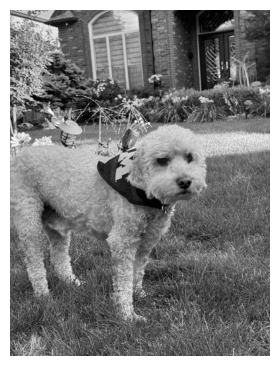

In [346]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the image and convert to grayscale
img = Image.open('imgs/junior.jpeg').convert('L')
img_arr = np.rot90(np.array(img), k=3)

# Show the grayscale image
plt.figure(figsize=(4*1.5, 3*1.5))
plt.imshow(img_arr, cmap='gray')
plt.axis('off')
plt.show()

This image is 300 pixels wide and 400 pixels tall. Since the image is grayscale, each pixel's intensity can be represented by a number between 0 and 255, where 0 is black and 255 is white. These intensities can be represented as a $400 \times 300$ matrix. The rank of this matrix is likely $300$, since it's extremely unlikely that any of the $300$ columns of the image are exactly representable as a linear combination of other columns.

But, as the SVD reveals, the image can be approximated well by a rank-$k$ matrix, for a $k$ that is much smaller than $300$. We build this low-rank approximation by summing up $k$ rank-one matrices.

$$\text{rank } k \text{ approximation of image} = \sum_{i=1}^k \sigma_i \vec u_i \vec v_i^T$$

Play with the slider that appears below to visualize a rank-$k$ approximation of the image.

In [ ]:
import numpy as np
import plotly.graph_objs as go
from PIL import Image

IMAGE_PATH = 'imgs/junior.jpeg'

# Load image (fallback to dummy if not found), rotate 90º clockwise, and resize to 3:4 aspect ratio (e.g., 300x400)
try:
    img = Image.open(IMAGE_PATH).convert('L')
    img = img.rotate(-90, expand=True)  # Rotate 90º clockwise
    img = img.resize((300, 400), Image.LANCZOS)  # 3:4 aspect ratio (width, height)
    img_arr = np.array(img)
except FileNotFoundError:
    H, W = 400, 300  # 3:4 aspect ratio
    img_arr = np.zeros((H, W), dtype=np.uint8)
    for i in range(H):
        for j in range(W):
            img_arr[i, j] = 200 if ((i // 10) % 2 == (j // 10) % 2) else 50

# Compute SVD
U, S, VT = np.linalg.svd(img_arr.astype(float), full_matrices=False)
max_k = len(S)

def get_reconstruction(k):
    k = max(1, min(k, len(S)))
    Uk = U[:, :k]
    Sk = S[:k]
    VTk = VT[:k, :]
    recon = Uk @ np.diag(Sk) @ VTk
    return 255 - np.clip(recon, 0, 255).astype(np.uint8)

# k=1, k=31, k=61, k=91, ..., max allowed (up to len(S))
ks = list(range(1, 51))
if ks[-1] != max_k-1:
    ks.append(max_k)

# Create frames (each frame is a Heatmap of the reconstructed image)
frames = []
for k in ks:
    z = get_reconstruction(k)
    frames.append(
        go.Frame(
            data=[
                go.Heatmap(
                    z=z,
                    zmin=0,
                    zmax=255,
                    colorscale=[[0, "white"], [1, "black"]],
                    showscale=False
                )
            ],
            name=str(k)
        )
    )

# Initial trace uses k=1
initial_z = get_reconstruction(1)
initial_trace = go.Heatmap(z=initial_z, zmin=0, zmax=255, colorscale=[[0, "white"], [1, "black"]], showscale=False)

fig = go.Figure(
    data=[initial_trace],
    frames=frames
)

# Slider that calls animate on each frame
slider_steps = []
for k in ks:
    step = {
        "args": [
            [str(k)],  # frame name
            {
                "frame": {"duration": 0, "redraw": True},
                "mode": "immediate",
                "transition": {"duration": 0}
            }
        ],
        "label": str(k),
        "method": "animate"
    }
    slider_steps.append(step)

sliders = [{
    "active": 0,
    "pad": {"t": 50},
    "steps": slider_steps,
    "currentvalue": {"prefix": "Rank k: ", "font": {"size": 14}}
}]

fig.update_layout(
    sliders=sliders,
    width=300,   # width matches aspect ratio
    height=480,  # height matches aspect ratio
    margin=dict(l=20, r=20, t=0, b=0),
    font=dict(family="Avenir"),
)

# Hide axes
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.update_yaxes(autorange="reversed")

fig.show()

To store the full image, we need to store $400 \cdot 300 = 120{,}000$ numbers. But to store a rank-$k$ approximation of the image, we only need to store $(1 + 400 + 300)k = 701k$ numbers – only the first $k$ singular values, along with $\vec u_1, \vec u_2, ..., \vec u_k$ (each of which has 400 numbers), and $\vec v_1, \vec v_2, ..., \vec v_k$ (each of which has 300 numbers). If we're satisfied with a rank-30 approximation, we only need to store $701 \cdot 30 = 21{,}030$ numbers, which is a compression of $\frac{120{,}000}{21{,}030} \approx 5.7$ times!

---

## Computing the SVD

The invariance of the negative signs. Not actually computing $X^TX$ or $XX^T$.

In [150]:
X = np.array([[3, 2, 5],
              [2, 3, 5],
              [2, -2, 0],
              [5, 5, 10]])
u, s, vt = np.linalg.svd(X)
u.shape, s.shape, vt.shape

((4, 4), (3,), (3, 3))

In [152]:
u

array([[-4.08248290e-01,  2.35702260e-01, -4.57353982e-01,
        -7.54059091e-01],
       [-4.08248290e-01, -2.35702260e-01, -6.80988664e-01,
         5.60385775e-01],
       [-9.34078423e-17,  9.42809042e-01, -5.59086707e-02,
         3.28611217e-01],
       [-8.16496581e-01, -1.15075004e-16,  5.69171323e-01,
         9.68366582e-02]])

---

## Key Takeaways